# 🍕 Food Calorie Estimator
## Notebook 02 — Data Preprocessing & EDA

**الهدف:**
- تنظيف البيانات (إزالة الـ units وتحويل لأرقام)
- معالجة الـ Missing Values
- اختيار الـ Features المهمة
- Exploratory Data Analysis
- حفظ الـ clean data

---
### 🧠 ليه الـ Preprocessing مهم؟
الـ ML models بتشتغل بالأرقام فقط.
لو بعتلها `72g` مش هتفهم — لازم تبعتلها `72.0`

**قاعدة في ML: Garbage in = Garbage out**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Libraries imported!')

✅ Libraries imported!


## 📂 Step 2 — Load Raw Data

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'raw', 'nutrition.csv'), index_col=0)
print(f'✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

✅ Loaded: 8789 rows × 76 columns


,name,serving_size,calories,total_fat,saturated_fat,cholesterol,sodium,choline,folate,folic_acid,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,Cornstarch,100 g,381,0.1g,NaN,0,9.00 mg,0.4 mg,0.00 mcg,0.00 mcg,...,0.05 g,0.009 g,0.016 g,0.025 g,0.00 mg,0.0 g,0.09 g,0.00 mg,0.00 mg,8.32 g
1,"Nuts, pecans",100 g,691,72g,6.2g,0,0.00 mg,40.5 mg,22.00 mcg,0.00 mcg,...,71.97 g,6.180 g,40.801 g,21.614 g,0.00 mg,0.0 g,1.49 g,0.00 mg,0.00 mg,3.52 g
2,"Eggplant, raw",100 g,25,0.2g,NaN,0,2.00 mg,6.9 mg,22.00 mcg,0.00 mcg,...,0.18 g,0.034 g,0.016 g,0.076 g,0.00 mg,0.0 g,0.66 g,0.00 mg,0.00 mg,92.30 g


## 🧹 Step 3 — Clean String Values → Numbers

**المشكلة:** القيم زي `72g` أو `0.00 mg` هي strings مش أرقام
**الحل:** نعمل function تشيل أي حرف وتسيب الرقم بس

**ليه regex؟** لأن الـ units مختلفة: `g`, `mg`, `mcg`, `IU` — regex بيتعامل معاهم كلهم بسطر واحد

In [3]:
def clean_numeric(value):
    '''
    بتحول أي value فيها unit لرقم.
    مثال: 72g → 72.0 | 0.00 mg → 0.0 | NaN → NaN
    '''
    if pd.isna(value):
        return np.nan
    value_str = str(value).strip()
    cleaned = re.sub(r'[^\d.-]', '', value_str)
    try:
        return float(cleaned)
    except:
        return np.nan

# تجربة
test_values = ['72g', '6.2g', '0.00 mg', '381', None, 'N/A']
print('🧪 Testing clean_numeric:')
for v in test_values:
    print(f'  {str(v):15} → {clean_numeric(v)}')

🧪 Testing clean_numeric:
  72g             → 72.0
  6.2g            → 6.2
  0.00 mg         → 0.0
  381             → 381.0
  None            → nan
  N/A             → nan


In [4]:
df_clean = df.copy()
text_cols = ['name']
numeric_cols = [col for col in df_clean.columns if col not in text_cols]

print(f'🔄 Converting {len(numeric_cols)} columns...')
for col in numeric_cols:
    df_clean[col] = df_clean[col].apply(clean_numeric)

print('✅ Done!')
print(f'Before: {df["total_fat"].dtype} → After: {df_clean["total_fat"].dtype}')
print(df_clean['total_fat'].head())

🔄 Converting 75 columns...
✅ Done!
Before: str → After: float64
0     0.1
1    72.0
2     0.2
3     2.4
4     2.0
Name: total_fat, dtype: float64


## 🎯 Step 4 — Feature Selection

**ليه بنختار features معينة بس؟**
عندنا 76 column — مش كلهم مفيدين.
الـ features كتير ممكن تعمل **Overfitting** أو تبطئ الـ training.

هنختار الـ **Macronutrients** الأساسية:
- **protein** → كل gram = 4 calories
- **fat** → كل gram = 9 calories
- **carbohydrate** → كل gram = 4 calories
- **fiber, sugars, sodium** → features إضافية مفيدة

In [5]:
FEATURES = [
    'protein', 'fat', 'carbohydrate',
    'fiber', 'sugars', 'sodium',
    'saturated_fatty_acids',
    'monounsaturated_fatty_acids',
    'polyunsaturated_fatty_acids'
]
TARGET = 'calories'

available = [f for f in FEATURES if f in df_clean.columns]
print(f'✅ Features: {available}')

df_selected = df_clean[['name'] + available + [TARGET]].copy()
print(f'📊 Shape: {df_selected.shape}')
df_selected.head()

✅ Features: ['protein', 'fat', 'carbohydrate', 'fiber', 'sugars', 'sodium', 'saturated_fatty_acids', 'monounsaturated_fatty_acids', 'polyunsaturated_fatty_acids']
📊 Shape: (8789, 11)


,name,protein,fat,carbohydrate,fiber,sugars,sodium,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,calories
0,Cornstarch,0.26,0.05,91.27,0.9,0.00,9.0,0.009,0.016,0.025,381.0
1,"Nuts, pecans",9.17,71.97,13.86,9.6,3.97,0.0,6.180,40.801,21.614,691.0
2,"Eggplant, raw",0.98,0.18,5.88,3.0,3.53,2.0,0.034,0.016,0.076,25.0
3,"Teff, uncooked",13.30,2.38,73.13,8.0,1.84,12.0,0.449,0.589,1.071,367.0
4,"Sherbet, orange",1.10,2.00,30.40,1.3,24.32,46.0,1.160,0.530,0.080,144.0


## 🔧 Step 5 — Handle Missing Values

**الاستراتيجيات:**
1. **Drop rows** → نخسر data
2. **Fill with mean** → الأشيع
3. **Fill with median** → أفضل لو في outliers ✅
4. **Fill with 0** → لو الـ null معناه غياب المادة

**إحنا هنستخدم median** — لأن القيم الغذائية فيها outliers كتير

In [6]:
print('⚠️  Missing values BEFORE:')
print(df_selected[available + [TARGET]].isnull().sum().to_string())

⚠️  Missing values BEFORE:
protein                        0
fat                            0
carbohydrate                   0
fiber                          0
sugars                         0
sodium                         0
saturated_fatty_acids          0
monounsaturated_fatty_acids    0
polyunsaturated_fatty_acids    0
calories                       0


In [7]:
# نشيل الصفوف اللي الـ target فيها null
df_selected = df_selected.dropna(subset=[TARGET])
print(f'✅ Rows after dropping null targets: {len(df_selected)}')

# نملأ باقي الـ nulls بالـ median
for col in available:
    median_val = df_selected[col].median()
    df_selected[col] = df_selected[col].fillna(median_val)

print('✅ Missing values AFTER:')
print(df_selected[available + [TARGET]].isnull().sum().to_string())

✅ Rows after dropping null targets: 8789
✅ Missing values AFTER:
protein                        0
fat                            0
carbohydrate                   0
fiber                          0
sugars                         0
sodium                         0
saturated_fatty_acids          0
monounsaturated_fatty_acids    0
polyunsaturated_fatty_acids    0
calories                       0


## 📊 Step 6 — EDA

**ليه EDA قبل الـ modeling؟**
- نفهم العلاقة بين الـ features والـ target
- نشوف الـ outliers
- نعرف أي feature أهم

/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/3259441963.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/3259441963.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../results/plots/02_feature_distributions.png', dpi=150, bbox_inches='tight')
/Users/abdulkadertamer/Desktop/Projects/food-calorie-estimator/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


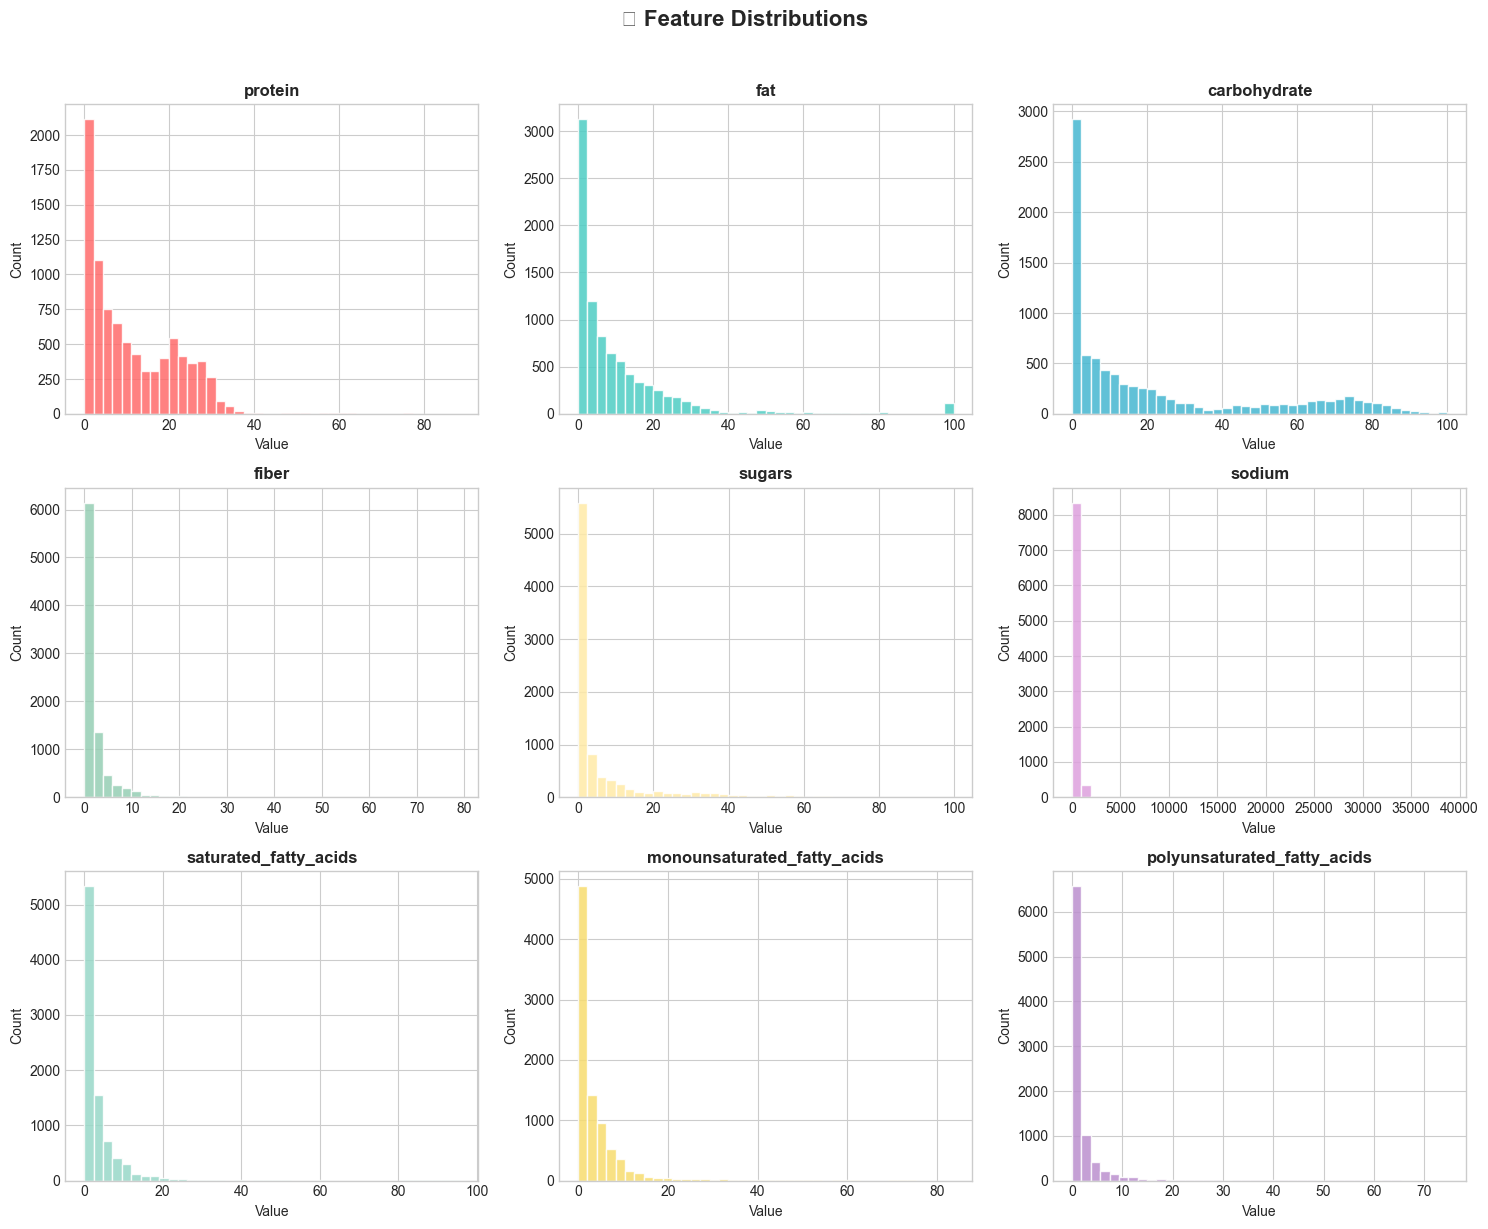

✅ Saved!


In [8]:
# Feature Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE']

for i, col in enumerate(available):
    axes[i].hist(df_selected[col].dropna(), bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('📊 Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/2438263392.py:8: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/2438263392.py:9: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.savefig('../results/plots/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
/Users/abdulkadertamer/Desktop/Projects/food-calorie-estimator/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


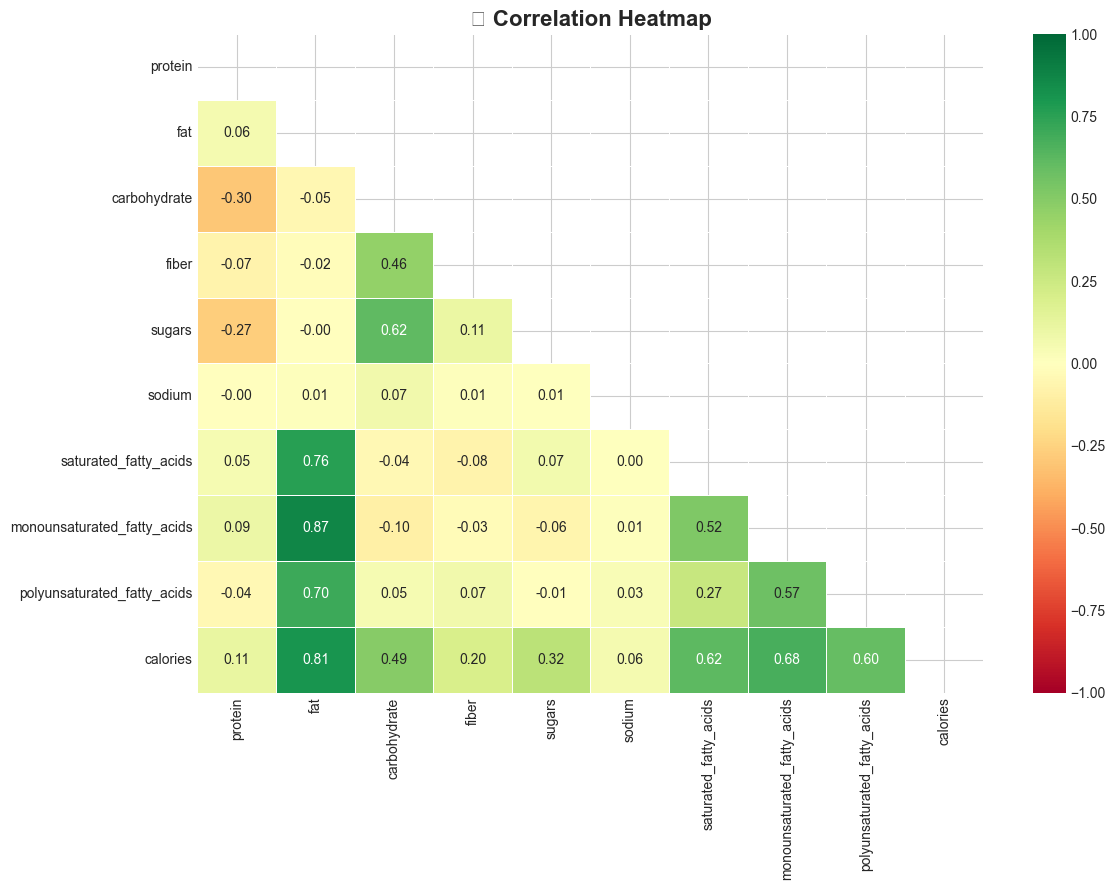

✅ Saved!


In [9]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df_selected[available + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('🔥 Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved!')

/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/1229221807.py:11: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/1229221807.py:12: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('../results/plots/02_scatter_plots.png', dpi=150, bbox_inches='tight')
/Users/abdulkadertamer/Desktop/Projects/food-calorie-estimator/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


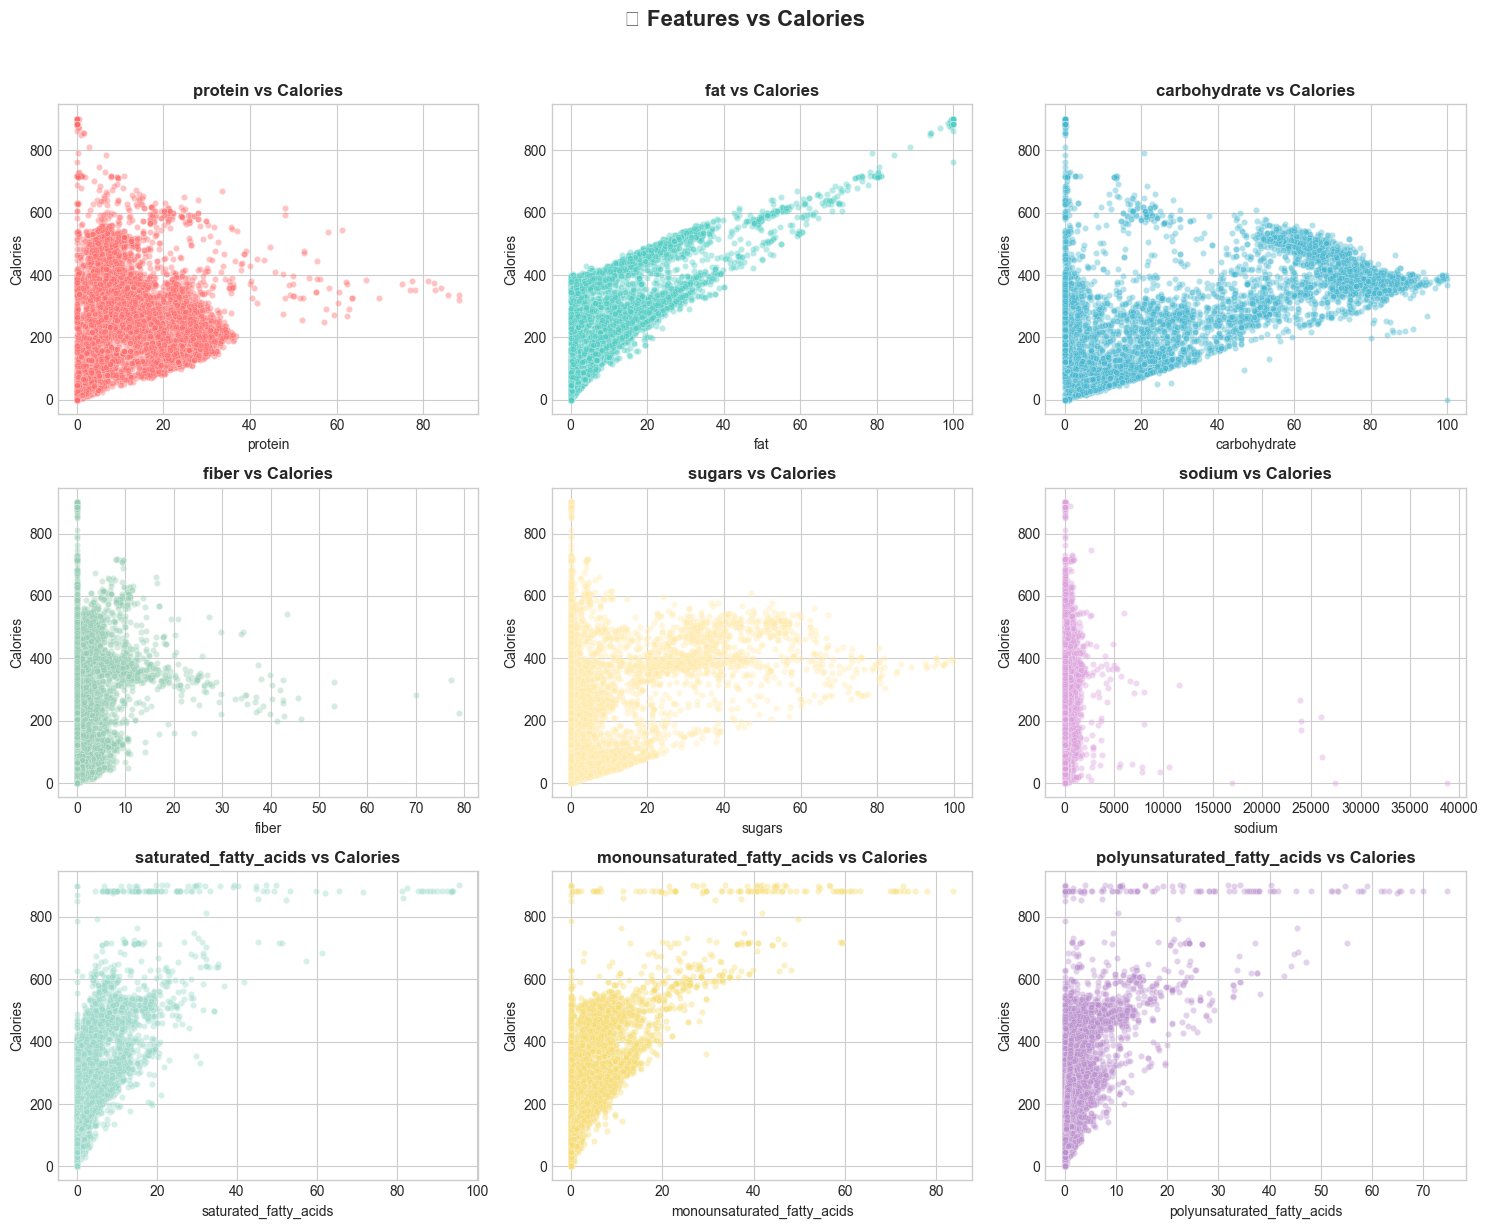

In [10]:
# Scatter plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(available):
    axes[i].scatter(df_selected[col], df_selected[TARGET],
                    alpha=0.4, color=colors[i], s=20, edgecolors='white', linewidth=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Calories')
    axes[i].set_title(f'{col} vs Calories', fontweight='bold')
plt.suptitle('🔍 Features vs Calories', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/plots/02_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/3199857273.py:10: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cd/t01bvvbs3b37ts7_46bprrn80000gn/T/ipykernel_68222/3199857273.py:11: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.savefig('../results/plots/02_top10_calories.png', dpi=150, bbox_inches='tight')


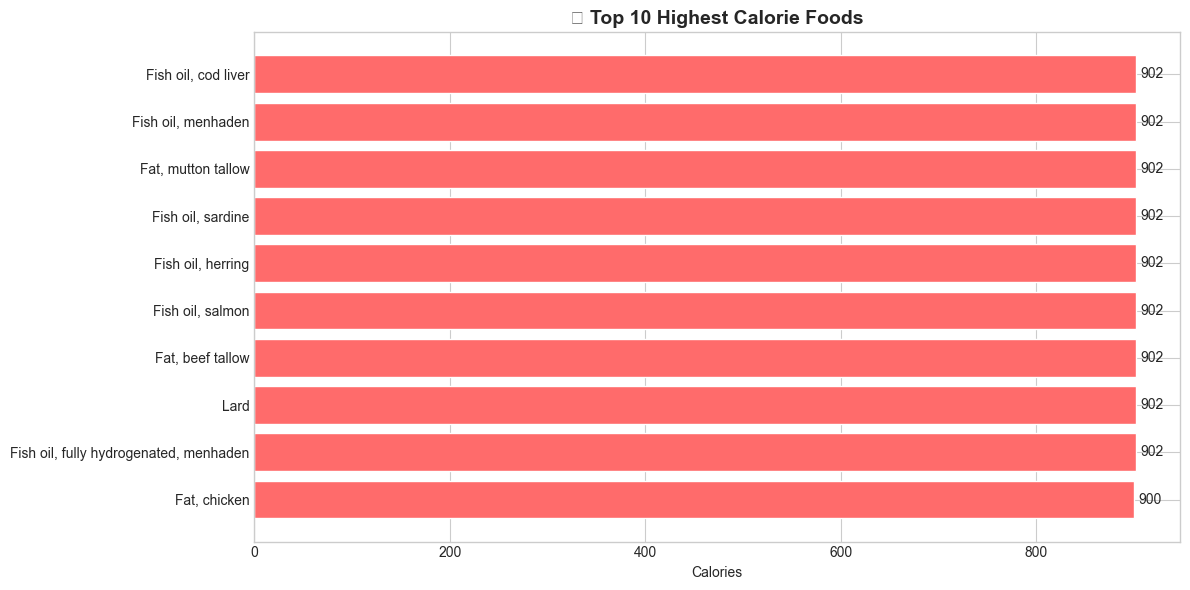

In [11]:
# Top 10 highest calorie foods
top10 = df_selected.nlargest(10, TARGET)[['name', TARGET]]
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['name'], top10[TARGET], color='#FF6B6B', edgecolor='white')
plt.xlabel('Calories')
plt.title('🔥 Top 10 Highest Calorie Foods', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top10[TARGET]):
    plt.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center')
plt.tight_layout()
plt.savefig('../results/plots/02_top10_calories.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 7 — Save Processed Data

**ليه بنحفظ في ملف منفصل؟**
عشان Notebook 03 يبدأ من الـ clean data مباشرة — **best practice في ML**

In [12]:
output_path = os.path.join('..', 'data', 'processed', 'nutrition_clean.csv')
df_selected.to_csv(output_path, index=False)
print(f'✅ Saved to: {output_path}')
print(f'📊 Shape: {df_selected.shape}')

✅ Saved to: ../data/processed/nutrition_clean.csv
📊 Shape: (8789, 11)


## ✅ Summary

In [13]:
print('='*55)
print('📋  NOTEBOOK 02 — SUMMARY')
print('='*55)
print('✅  Cleaned strings    → float numbers')
print(f'✅  Selected features  : {len(available)}')
print('✅  Missing values     → filled with median')
print('✅  EDA plots saved    → results/plots/')
print(f'📊  Final dataset      : {df_selected.shape[0]:,} samples')
print('='*55)
corr_with_target = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('\n🔝 Top features correlated with calories:')
for feat, corr in corr_with_target.head(5).items():
    print(f'   {feat:35} → {corr:.3f}')
print('\n🚀 Next → Notebook 03: Model Training')

📋  NOTEBOOK 02 — SUMMARY
✅  Cleaned strings    → float numbers
✅  Selected features  : 9
✅  Missing values     → filled with median
✅  EDA plots saved    → results/plots/
📊  Final dataset      : 8,789 samples

🔝 Top features correlated with calories:
   fat                                 → 0.807
   monounsaturated_fatty_acids         → 0.677
   saturated_fatty_acids               → 0.619
   polyunsaturated_fatty_acids         → 0.595
   carbohydrate                        → 0.493

🚀 Next → Notebook 03: Model Training
